# Data Preparation and Data Cleaning

In [33]:
!pipenv install optuna ucimlrepo "mlflow>3.0.0" seaborn xgboost

To activate this project's virtualenv, run pipenv shell.
Alternatively, run a command inside the virtualenv with pipenv run.
Installing optuna...
Installation Succeeded
Installing ucimlrepo...
Installation Succeeded
Installing mlflow>3.0.0...
Installation Succeeded
Installing seaborn...
Installation Succeeded
Installing xgboost...
Installation Succeeded
To activate this project's virtualenv, run pipenv shell.
Alternatively, run a command inside the virtualenv with pipenv run.
Installing dependencies from Pipfile.lock (b390a9)...
All dependencies are now up-to-date!
Building requirements...
[    ] Locking packages...
Resolving dependencies...
[    ] Locking packages...
[=   ] Locking packages...
[==  ] Locking packages...
[=== ] Locking packages...
[ ===] Locking packages...
[  ==] Locking packages...
[   =] Locking packages...
[    ] Locking packages...
[   =] Locking packages...
[  ==] Locking packages...
[ ===] Locking packages...
[====] Locking packages...
[=== ] Locking packages...

Loading .env environment variables...
Courtesy Notice:
Pipenv found itself running within a virtual environment,  so it will 
automatically use that environment, instead of  creating its own for any 
project. You can set
PIPENV_IGNORE_VIRTUALENVS=1 to force pipenv to ignore that environment and 
create  its own instead.
You can set PIPENV_VERBOSITY=-1 to suppress this warning.
Upgrading optuna, ucimlrepo, mlflow>3.0.0, seaborn, xgboost in  dependencies.


In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
data_uci = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = data_uci.data.features # type: ignore # tyoe: ignore
y = data_uci.data.targets  # type: ignore
  
# metadata 
print(data_uci.metadata) 
  
# variable information 
print(data_uci.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

# EDA



In [ ]:
print(X.isnal.sum())
print(y.isna().sum())

In [2]:

# 1. Lista explícita de tus variables categóricas demográficas y demas
X_cat = ['X3', 'X2', 'X4', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11']

X_num = [col for col in X.columns if col not in X_cat]

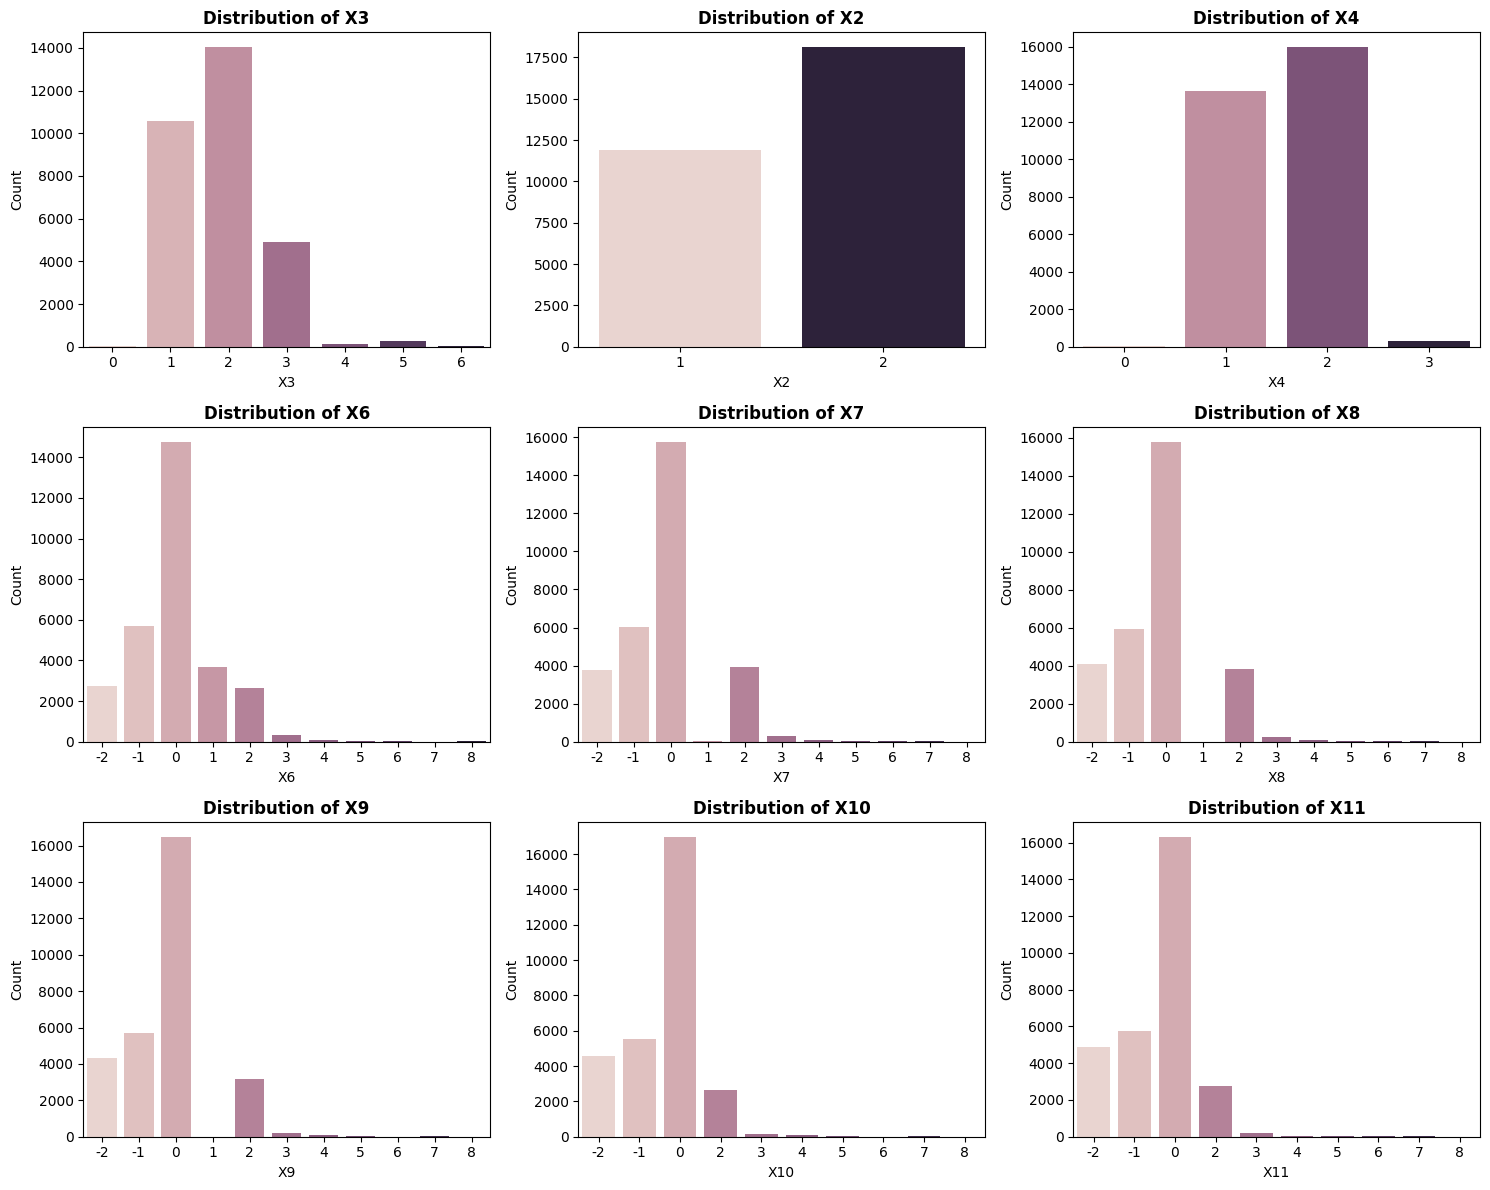

In [3]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_plots = len(X_cat)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4* n_rows))

if n_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(X_cat):
    ax = axes[i]
    
    counts = X[col].value_counts().sort_values(ascending=False)
    

    sns.barplot(x=counts.index, y=counts.values, ax=ax, hue=counts.index, legend=False)
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150)

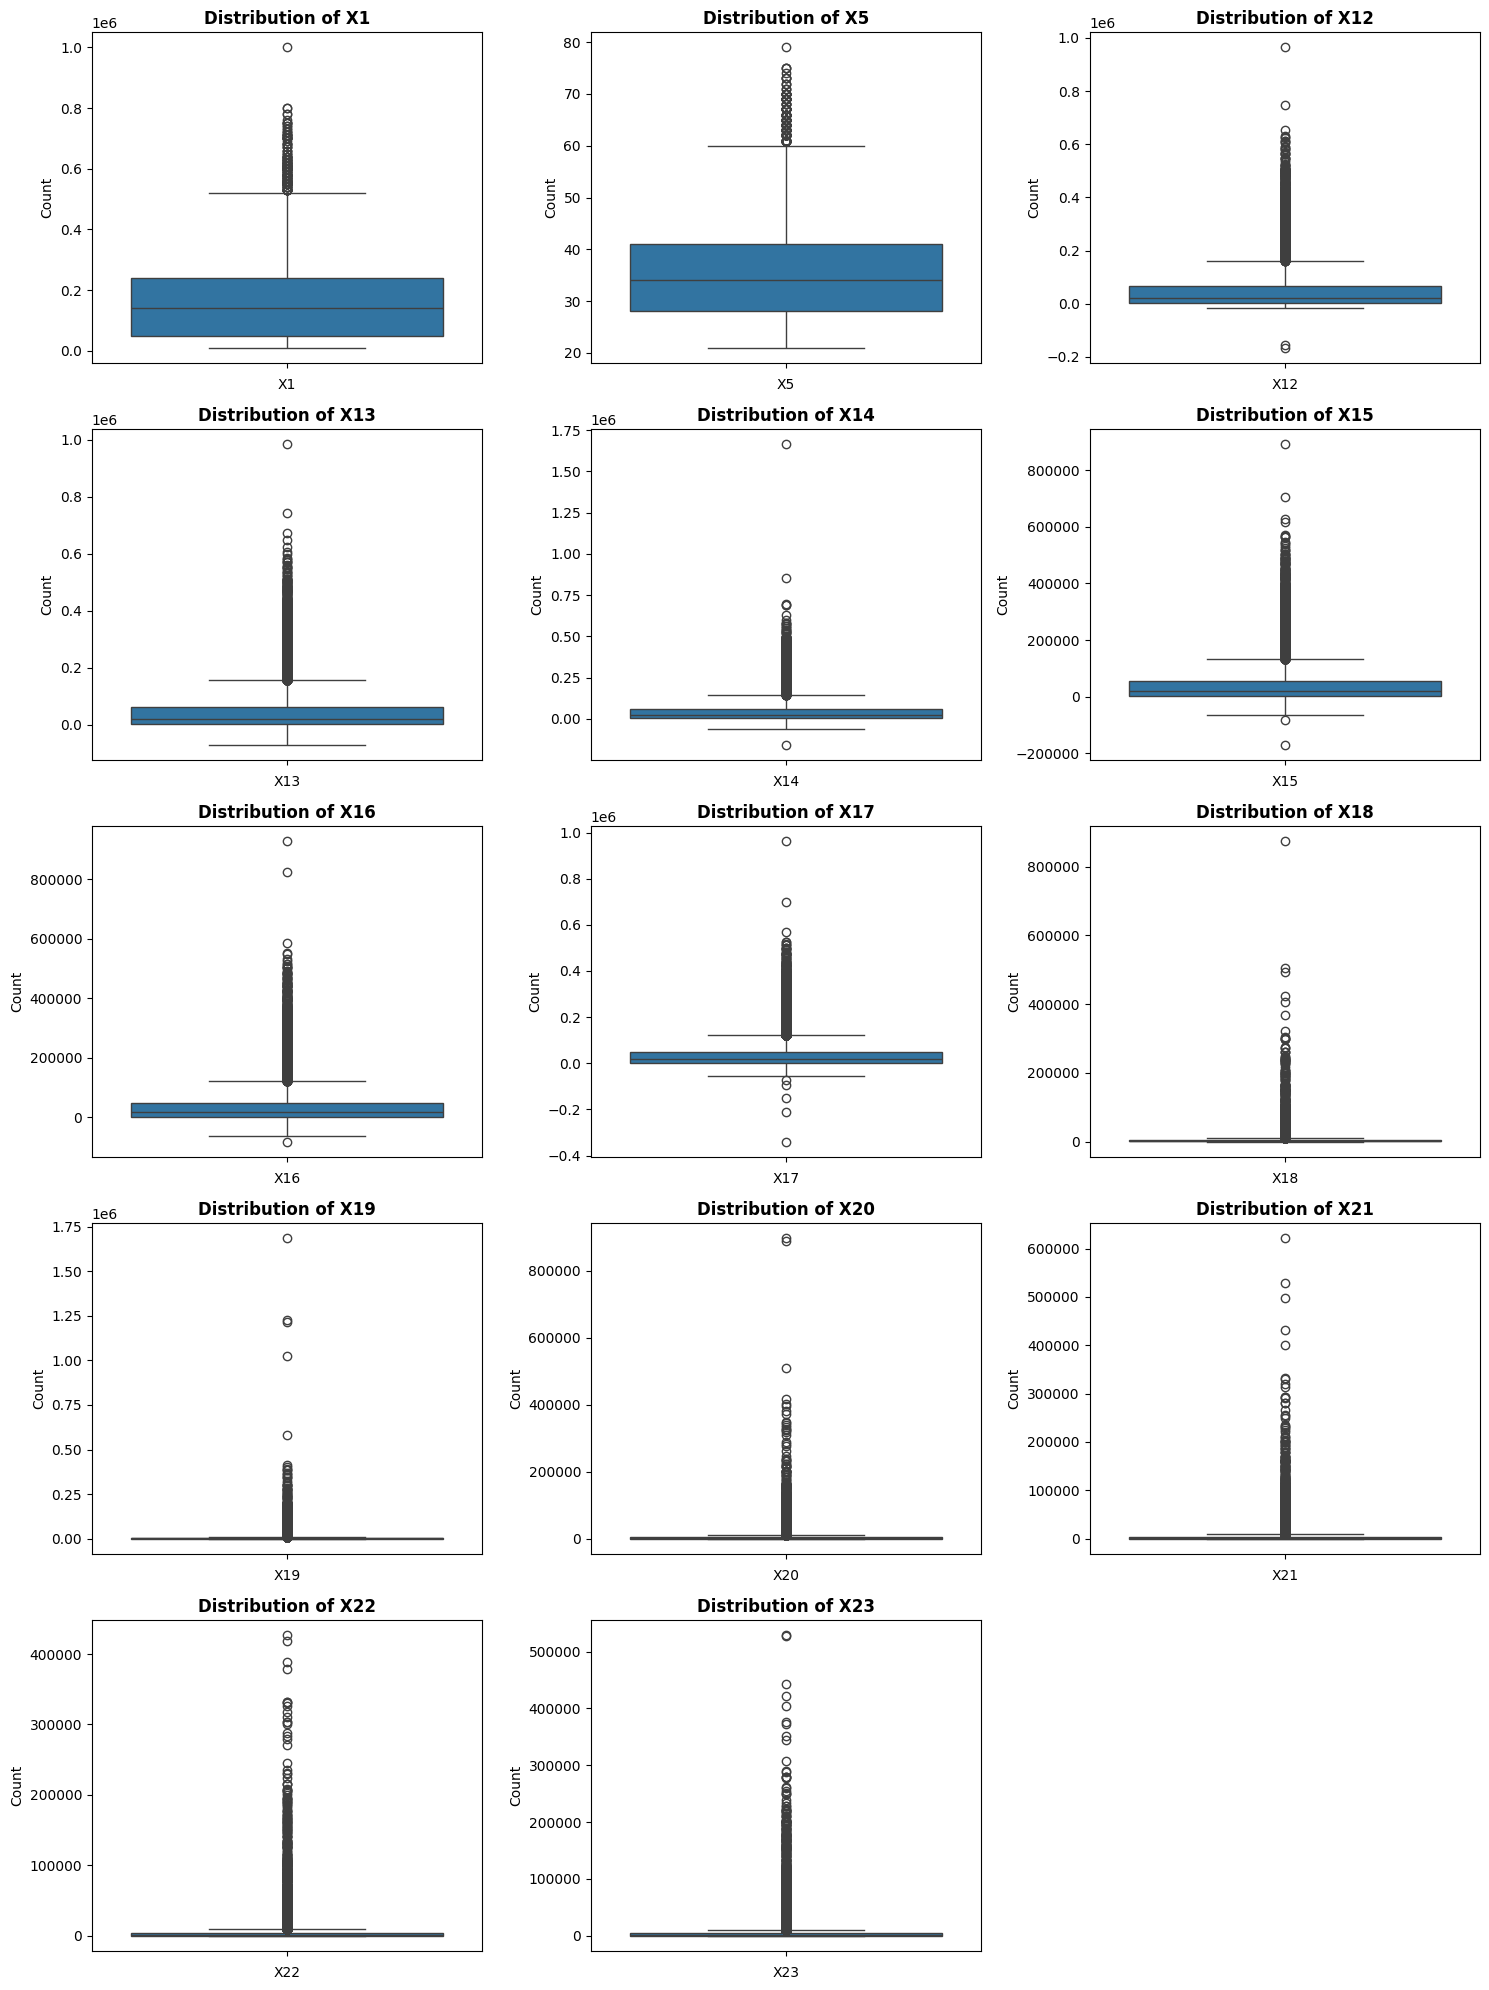

In [4]:
n_cols = 3
n_plots = len(X_num)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4* n_rows))

if n_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(X_num):
    ax = axes[i]
    
    

    sns.boxplot(X[col], ax=ax)
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150)

C:\Users\juane\AppData\Local\Temp\ipykernel_8080\2749962686.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Y', data=y, palette='viridis')


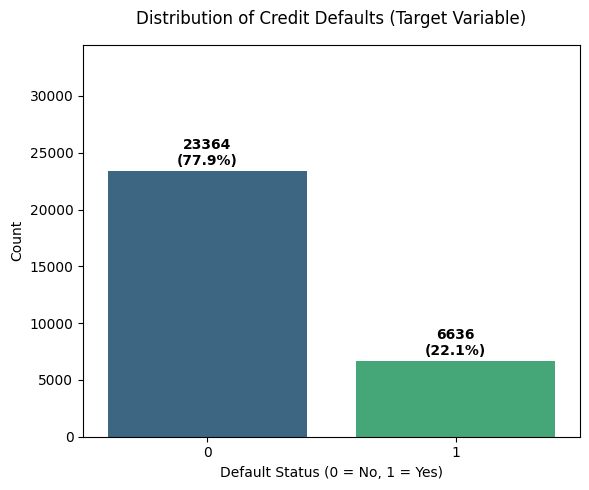

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

# 1. Capture the axes object ('ax') from the plot
ax = sns.countplot(x='Y', data=y, palette='viridis')

# 2. Calculate the total number of observations for percentage math
total = len(y)

# 3. Loop through the bars (patches) and add text labels
for p in ax.patches:
    # Get the height of each bar (which is the count)
    count = int(p.get_height())
    # Calculate the percentage relative to the dataset total
    percentage = f'{100 * count / total:.1f}%'
    
    # Combine count and percentage into a two-line string
    label = f'{count}\n({percentage})'
    
    # Position the text at the top-center of each bar
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = count + (total * 0.01) # Small padding above the bar
    
    ax.text(x_pos, y_pos, label, ha='center', va='bottom', fontsize=10, weight='bold')

plt.title("Distribution of Credit Defaults (Target Variable)", fontsize=12, pad=15)
plt.xlabel('Default Status (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Dynamically boost the y-axis limit slightly so text labels don't get clipped off the top
plt.ylim(0, total * 1.15)

plt.tight_layout()
plt.show()

The target variable exhibits a moderate class imbalance, with 22.1% of customers defaulting and 77.9% remaining non-defaulting. While the imbalance is not extreme, a naive classifier that always predicts "no default" would achieve an accuracy of 77.9%, making accuracy alone an unreliable performance metric.


Because nearly four out of five customers belong to the non-default class, model evaluation should emphasize metrics such as ROC AUC, Precision, Recall, and F1 Score rather than accuracy alone. A model reporting high accuracy may simply be exploiting the class distribution without effectively identifying future defaulters.


The minority class represents the most economically important observations in the dataset. Although only 22.1% of customers default, these accounts generate the majority of credit risk exposure. Consequently, correctly identifying defaulters is often more valuable than maximizing overall classification accuracy.

Although the dataset is only moderately imbalanced (22.1% defaults), the imbalance is sufficient to make accuracy a potentially misleading metric. This motivates the use of class-balanced learning, Precision-Recall analysis, and threshold optimization throughout model development.

In [6]:
df = pd.concat([y, X], axis=1)

In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
dtypes: int64(23)
memory us

In [8]:
df.groupby("X2")["Y"].mean()

X2
1    0.241672
2    0.207763
Name: Y, dtype: float64

24.17% of males defaulted
20.78% of females defaulted

In [9]:
df.groupby("X3")["Y"].mean()

X3
0    0.000000
1    0.192348
2    0.237349
3    0.251576
4    0.056911
5    0.064286
6    0.156863
Name: Y, dtype: float64

In [10]:
df.groupby("X3").agg(
    count=("Y","size"),
    default_rate=("Y","mean")
    )

,count,default_rate
X3,,
0,14,0.000000
1,10585,0.192348
2,14030,0.237349
3,4917,0.251576
4,123,0.056911
5,280,0.064286
6,51,0.156863


1 = Graduate School
2 = University
3 = High School
4 = Others

Default rates increase as education level decreases. Customers with graduate education exhibit the lowest default rate (19.2%), followed by university graduates (23.7%) and high school graduates (25.2%). This suggests that education level may contain predictive information related to repayment behavior and credit risk.


In [11]:
df.groupby("X4")["Y"].mean()

X4
0    0.092593
1    0.234717
2    0.209283
3    0.260062
Name: Y, dtype: float64

1 = Married
2 = Single
3 = Other
0 = Undocumented / anomalous category

Default rates vary moderately across marital-status groups. Married customers exhibit a default rate of 23.5%, while single customers show a lower default rate of 20.9%.

Customers classified as "other" marital status display the highest default rate (26.0%). However, this category typically represents a much smaller portion of the dataset and should therefore be interpreted with caution.

Overall, marital status appears to contain predictive information, although the differences are substantially smaller than those observed for repayment-history variables. Consequently, marital status is expected to contribute modestly to predictive performance when combined with stronger behavioral features.

In [12]:
df.groupby("X6")["Y"].mean()

X6
-2    0.132294
-1    0.167781
 0    0.128113
 1    0.339479
 2    0.691414
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: Y, dtype: float64

Repayment status is the strongest predictor observed during exploratory data analysis. Customers who paid on time or paid in advance (statuses -2, -1, and 0) exhibit default rates between 12% and 17%.

However, default risk increases dramatically once a payment delay occurs. Customers with a one-month payment delay (status 1) show a default rate of 33.9%, more than double that of customers with no recent delinquency.

The effect becomes even more pronounced for longer delays. Customers who are two months late (status 2) exhibit a default rate of 69.1%, while those who are three months late (status 3) reach a default rate of 75.8%.

This monotonic increase in default risk confirms that repayment history contains substantial predictive information and justifies its central role in credit-risk modeling. The strong relationship observed in X6 motivated the creation of repayment-based engineered features such as `ever_late`, `max_delay`, `delay_trend`, and `good_payment_ratio`, which summarize delinquency behavior across multiple months.

In [13]:
repayment_cols = ["X6", "X7", "X8", "X9", "X10", "X11"]

summary = pd.DataFrame()

for col in repayment_cols:
    summary[col] = (
        df.groupby(col)["Y"]
          .mean()
          .round(3)
    )

summary

,X6,X7,X8,X9,X10,X11
X6,,,,,,
-2,0.132,0.183,0.185,0.193,0.197,0.200
-1,0.168,0.160,0.156,0.159,0.162,0.170
0,0.128,0.159,0.175,0.183,0.189,0.188
1,0.339,0.179,0.250,0.500,NaN,NaN
2,0.691,0.556,0.516,0.523,0.542,0.507
3,0.758,0.617,0.575,0.611,0.635,0.641
4,0.684,0.505,0.579,0.667,0.607,0.633
5,0.500,0.600,0.571,0.514,0.588,0.538
6,0.545,0.750,0.609,0.400,0.750,0.737


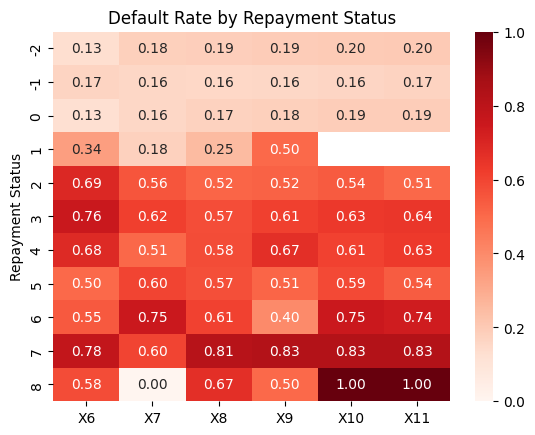

In [14]:
repayment_cols = ["X6", "X7", "X8", "X9", "X10", "X11"]

summary = pd.DataFrame()

for col in repayment_cols:
    summary[col] = df.groupby(col)["Y"].mean()

sns.heatmap(
    summary,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Default Rate by Repayment Status")
plt.ylabel("Repayment Status")
plt.show()

A consistent relationship is observed across all six repayment-status variables (X6–X11). Customers who paid on time or ahead of schedule (statuses -2, -1, and 0) exhibit default rates between approximately 13% and 20%.

However, default risk increases sharply once payment delinquency occurs. Customers with a two-month payment delay typically exhibit default rates above 50%, while customers with delays of three months or more frequently exceed 60–80% default rates.

This pattern is remarkably stable across all six months of repayment history, indicating that delinquency behavior is the most informative predictor of future default in the dataset.

The strong relationship between repayment status and default risk motivated the creation of repayment-based engineered features such as `ever_late`, `max_delay`, `delay_trend`, and `good_payment_ratio`, which summarize customer payment behavior over time.

In [15]:
pd.DataFrame({
    "On Time or Better": [
        df[df["X6"] <= 0]["Y"].mean()
    ],
    "1 Month Late": [
        df[df["X6"] == 1]["Y"].mean()
    ],
    "2+ Months Late": [
        df[df["X6"] >= 2]["Y"].mean()
    ]
}).T

,0
On Time or Better,0.138340
1 Month Late,0.339479
2+ Months Late,0.695527


Y           0          1
X6                      
-2  86.770569  13.229431
-1  83.221949  16.778051
 0  87.188709  12.811291
 1  66.052061  33.947939
 2  30.858643  69.141357
 3  24.223602  75.776398
 4  31.578947  68.421053
 5  50.000000  50.000000
 6  45.454545  54.545455
 7  22.222222  77.777778
 8  42.105263  57.894737


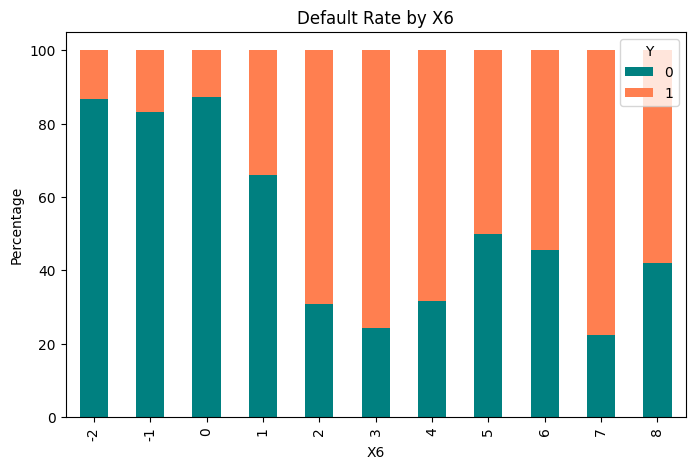

In [16]:
# Assuming X_cat[0] is a categorical variable like Education or Gender
crosstab = pd.crosstab(X['X6'], y.squeeze(), normalize='index') * 100
print(crosstab)

# Plot as a stacked bar chart
crosstab.plot(kind='bar', stacked=True, color=['teal', 'coral'], figsize=(8, 5))
plt.title(f'Default Rate by X6')
plt.ylabel('Percentage')
plt.show()

# Feature Eng.

In [17]:
# since we have from x6-x11 ordinal data we need to apply OrdinalEcoder

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# over the 6 month the client has ever been late
X['ever_late'] = (X[['X6','X7','X8','X9','X10','X11']] >= 1).any(axis=1).astype(int)

# the max delay observed
X['max_delay'] = X[['X6','X7','X8','X9','X10','X11']].clip(lower=0).max(axis=1)

# is this improving or not?
X['delay_trend'] = X['X11'] - X['X6']  

# good performace ratio over the past 6 months
good = (X[['X6','X7','X8','X9','X10','X11']] <= -1)
X['good_payment_ratio'] = good.sum(axis=1) / 6

X_repayment = ['X6', 'X7', 'X8', 'X9', 'X10', 'X11']
X_derived   = ['ever_late', 'max_delay', 'delay_trend', 'good_payment_ratio']

# Expanded to include 9 and 10 which are present in your dataset
single_repayment_order = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Create a list of 6 lists (one for each of the 6 columns)
repayment_categories = [single_repayment_order for _ in range(6)] 



# feature importance analysis

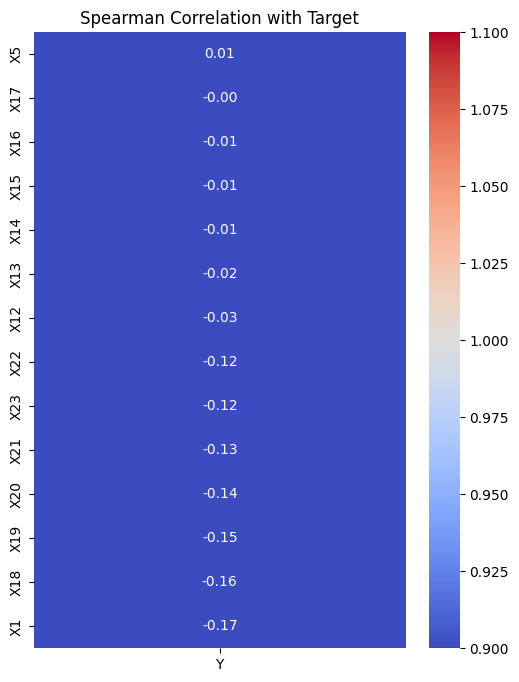

In [18]:
from scipy.stats import spearmanr
corr_df = pd.concat([X[X_num], y], axis=1)
corr_matrix, p_values = spearmanr(corr_df)
corr_df_ = pd.DataFrame(corr_matrix, index=corr_df.columns, columns=corr_df.columns)

target_corr = corr_df_[['Y']].drop('Y').sort_values(by='Y', ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=1, vmax=1, fmt='.2f')
plt.title("Spearman Correlation with Target")
plt.show()


In [19]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

discrete_cols = [
    'X6','X7','X8','X9','X10','X11',
    'ever_late'
]

discrete_mask = [
    col in discrete_cols
    for col in X.columns
]

mi_scores = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X.columns
).sort_values(ascending=False)

mi_scores = pd.Series(
    mi_scores,
    index=X.columns,
    name="MI Scores"
).sort_values(ascending=True)

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


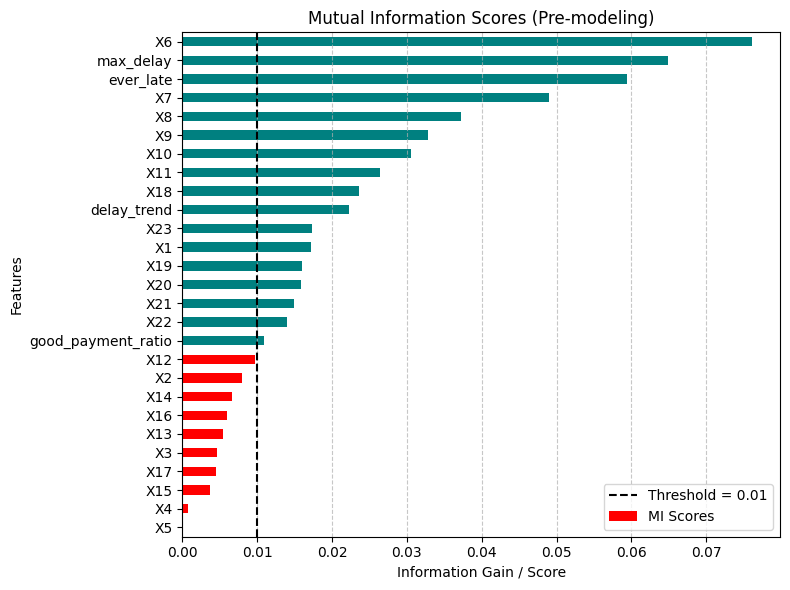

In [20]:
threshold = 0.01

colors = [
    'red' if score < threshold else 'teal'
    for score in mi_scores
]

plt.figure(figsize=(8, 6))
mi_scores.plot(
    kind='barh',
    color=colors
)

plt.axvline(
    threshold,
    color='black',
    linestyle='--',
    label=f'Threshold = {threshold}'
)

plt.title("Mutual Information Scores (Pre-modeling)")
plt.xlabel("Information Gain / Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig(
    "plots/mutual_information_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Model selection


In [21]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
import time, joblib, os, tempfile
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler


def make_pipeline(clf):
    return Pipeline([
        ('pre', ColumnTransformer(transformers=[
            ('num', RobustScaler(), X_num),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), X_cat),
            ('rep', OrdinalEncoder(categories=repayment_categories, handle_unknown='use_encoded_value', unknown_value=-1), X_repayment),
            ('der', RobustScaler(), X_derived),
        ])),
        ('clf', clf)
    ])




X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.squeeze(),
    test_size=0.2,
    stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # for xgboost

results = {}

models = {
    'Logistic Regression':  make_pipeline(LogisticRegression(class_weight='balanced', max_iter=1000)),
    'Random Forest':        make_pipeline(RandomForestClassifier(class_weight='balanced', n_jobs=-1)),
    'HistGradientBoosting': make_pipeline(HistGradientBoostingClassifier(class_weight='balanced')),
    'XGBoost':              make_pipeline(XGBClassifier(scale_pos_weight=scale_pos_weight,
                                                        eval_metric='logloss', n_jobs=-1)),
    'LightGBM':             make_pipeline(LGBMClassifier(class_weight='balanced', n_jobs=-1)),
    'VotingClassifier':     VotingClassifier(estimators=[
                                ('lr',   make_pipeline(LogisticRegression(class_weight='balanced'))),
                                ('hgb',  make_pipeline(HistGradientBoostingClassifier(class_weight='balanced'))),
                                ('lgbm', make_pipeline(LGBMClassifier(class_weight='balanced', n_jobs=-1))),
                            ], voting='soft', n_jobs=-1),
}
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}


results = {}
for name, model in models.items():
    start = time.time()
    cv_results = cross_validate(
        model, X, y.values.ravel().astype(int),         
        cv=StratifiedKFold(5),
        scoring=scoring_metrics,
        return_train_score=True
    )
    elapsed = time.time() - start

    model.fit(X_train, y_train)         
    with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
        tmp_path = f.name
    joblib.dump(model, tmp_path)
    pkl_kb = os.path.getsize(tmp_path) / 1024
    os.unlink(tmp_path)

    results[name] = {
        'accuracy_mean':  cv_results['test_accuracy'].mean(),
        'precision_mean': cv_results['test_precision'].mean(),
        'recall_mean':    cv_results['test_recall'].mean(),
        'f1_mean':        cv_results['test_f1'].mean(),
        'roc_auc_mean':        cv_results['test_roc_auc'].mean(),
        'overfit_gap':    round(cv_results['train_f1'].mean() - cv_results['test_f1'].mean(), 3),
        'train_time_s':   round(elapsed, 1),
        'pkl_kb':         round(pkl_kb, 1),
    }

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.p

[LightGBM] [Info] Number of positive: 5308, number of negative: 18692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002454 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3377
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001802 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3372
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but 

...

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3378
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002452 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3382
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-defaul

In [22]:
df = pd.DataFrame(results).T

df.index.name = 'Model'

# 1. ADD 'roc_auc_mean' to the column selection
df = df[['roc_auc_mean', 'f1_mean', 'precision_mean', 'recall_mean', 'accuracy_mean', 'overfit_gap', 'train_time_s', 'pkl_kb']]

# 2. ADD 'ROC AUC' to the column renaming
df.columns = ['ROC AUC', 'F1', 'Precision', 'Recall', 'Accuracy', 'Overfit Gap', 'Train Time (s)', 'PKL (KB)']

# cast to float so styling works
df = df.astype(float)

def highlight_table(df):
    styled = df.style

    # metrics where higher = better (green scale)
    for col in ['ROC AUC', 'F1', 'Precision', 'Recall', 'Accuracy']:
        styled = styled.background_gradient(cmap='Greens', subset=[col], vmin=0, vmax=1)

    # metrics where lower = better (reverse green = red for high values)
    for col in ['Overfit Gap', 'Train Time (s)', 'PKL (KB)']:
        styled = styled.background_gradient(cmap='RdYlGn_r', subset=[col])

    styled = styled.format({
        'F1':           '{:.3f}',
        'Precision':    '{:.3f}',
        'Recall':       '{:.3f}',
        'Accuracy':     '{:.3f}',
        'Overfit Gap':  '{:.3f}',
        'Train Time (s)': '{:.1f}',
        'PKL (KB)':     '{:,.0f}',
    })

    return styled

highlight_table(df)

,ROC AUC,F1,Precision,Recall,Accuracy,Overfit Gap,Train Time (s),PKL (KB)
Model,,,,,,,,
Logistic Regression,0.769428,0.531,0.467,0.615,0.759,0.002,8.8,8
Random Forest,0.765740,0.519,0.553,0.489,0.799,0.472,6.8,"70,011"
HistGradientBoosting,0.781971,0.534,0.463,0.633,0.756,0.049,16.1,170
XGBoost,0.761825,0.513,0.459,0.584,0.755,0.247,3.1,374
LightGBM,0.780553,0.536,0.468,0.628,0.759,0.095,2.7,350
VotingClassifier,0.784099,0.539,0.479,0.618,0.766,0.046,28.9,549


# Tuning best model

In [23]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # --- Tune Logistic Regression ---
    lr_c = trial.suggest_float("lr_C", 1e-4, 10.0, log=True)
    lr_pipeline = make_pipeline(
        LogisticRegression(C=lr_c, class_weight="balanced", random_state=42)
    )

    # --- Tune HistGradientBoosting ---
    hgb_lr = trial.suggest_float("hgb_learning_rate", 0.01, 0.2, log=True)
    hgb_max_iter = trial.suggest_int("hgb_max_iter", 50, 200)
    hgb_pipeline = make_pipeline(
        HistGradientBoostingClassifier(
            learning_rate=hgb_lr,
            max_iter=hgb_max_iter,
            class_weight="balanced",
            random_state=42,
        )
    )

    # --- Tune LGBMClassifier ---
    lgbm_lr = trial.suggest_float("lgbm_learning_rate", 0.01, 0.2, log=True)
    lgbm_n_est = trial.suggest_int("lgbm_n_estimators", 50, 200)
    lgbm_num_leaves = trial.suggest_int("lgbm_num_leaves", 15, 63)
    lgbm_pipeline = make_pipeline(
        LGBMClassifier(
            learning_rate=lgbm_lr,
            n_estimators=lgbm_n_est,
            num_leaves=lgbm_num_leaves,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
            verbosity=-1,  # Keeps the logs clean
        )
    )

    # --- Tune Voting Weights (Optional but highly recommended) ---
    w_lr = trial.suggest_float("w_lr", 0.0, 1.0)
    w_hgb = trial.suggest_float("w_hgb", 0.0, 1.0)
    w_lgbm = trial.suggest_float("w_lgbm", 0.0, 1.0)

    # 3. Construct the VotingClassifier with trial parameters
    ensemble = VotingClassifier(
        estimators=[
            ("lr", lr_pipeline),
            ("hgb", hgb_pipeline),
            ("lgbm", lgbm_pipeline),
        ],
        voting="soft",
        weights=[w_lr, w_hgb, w_lgbm],
        n_jobs=-1,
    )

    # 4. Evaluate using Cross-Validation
    # Using roc_auc because class_weight='balanced' implies an imbalanced dataset
    score = cross_val_score(
        ensemble, X, y, cv=5, scoring="roc_auc", n_jobs=-1
    ).mean()

    return score

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\n--- Optimization Finished ---")
print(f"Best Trial Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-10 12:12:30,758] A new study created in memory with name: no-name-6e08f0a1-7581-468a-8588-482075017931
[I 2026-06-10 12:12:40,701] Trial 0 finished with value: 0.7829676935599743 and parameters: {'lr_C': 0.06439669110138595, 'hgb_learning_rate': 0.03349744430674694, 'hgb_max_iter': 54, 'lgbm_learning_rate': 0.10285075970421644, 'lgbm_n_estimators': 132, 'lgbm_num_leaves': 27, 'w_lr': 0.6336716918940399, 'w_hgb': 0.6776052424926661, 'w_lgbm': 0.3820356228034857}. Best is trial 0 with value: 0.7829676935599743.
[I 2026-06-10 12:12:55,113] Trial 1 finished with value: 0.7794961172521385 and parameters: {'lr_C': 0.015650345795448124, 'hgb_learning_rate': 0.030873620753425333, 'hgb_max_iter': 183, 'lgbm_learning_rate': 0.01032112637358613, 'lgbm_n_estimators': 72, 'lgbm_num_leaves': 18, 'w_lr': 0.9622540978280534, 'w_hgb': 0.2186625244985465, 'w_lgbm': 0.8366358125363579}. Best is trial 0 with value: 0.7829676935599743.
[I 2026-06-10 12:13:04,753] Trial 2 finished with value: 0.7


--- Optimization Finished ---
Best Trial Score: 0.7842
Best Hyperparameters:
  lr_C: 9.950633950540384
  hgb_learning_rate: 0.10843557519505803
  hgb_max_iter: 142
  lgbm_learning_rate: 0.033553239080194086
  lgbm_n_estimators: 108
  lgbm_num_leaves: 46
  w_lr: 0.3052823704142444
  w_hgb: 0.6893937393677355
  w_lgbm: 0.5908257623071462


# Tuning 2d best model

In [25]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

    # --- Tune LGBMClassifier ---
    lgbm_lr = trial.suggest_float("lgbm_learning_rate", 0.01, 0.2, log=True)
    lgbm_n_est = trial.suggest_int("lgbm_n_estimators", 50, 200)
    lgbm_num_leaves = trial.suggest_int("lgbm_num_leaves", 15, 63)
    lgbm_pipeline = make_pipeline(
        LGBMClassifier(
            learning_rate=lgbm_lr,
            n_estimators=lgbm_n_est,
            num_leaves=lgbm_num_leaves,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
            verbosity=-1,  # Keeps the logs clean
        )
    )


    # 4. Evaluate using Cross-Validation
    # Using roc_auc because class_weight='balanced' implies an imbalanced dataset
    score = cross_val_score(
        lgbm_pipeline, X, y, cv=5, scoring="roc_auc", n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\n--- Optimization Finished ---")
print(f"Best Trial Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-10 12:18:11,699] A new study created in memory with name: no-name-c711cc2e-177f-4b33-8ea2-7d63c8a692ef
[I 2026-06-10 12:18:13,464] Trial 0 finished with value: 0.7835688289005988 and parameters: {'lgbm_learning_rate': 0.0374040556098891, 'lgbm_n_estimators': 167, 'lgbm_num_leaves': 21}. Best is trial 0 with value: 0.7835688289005988.
[I 2026-06-10 12:18:14,909] Trial 1 finished with value: 0.7796804177326868 and parameters: {'lgbm_learning_rate': 0.014824281716646261, 'lgbm_n_estimators': 63, 'lgbm_num_leaves': 41}. Best is trial 0 with value: 0.7835688289005988.
[I 2026-06-10 12:18:16,726] Trial 2 finished with value: 0.7812268357671478 and parameters: {'lgbm_learning_rate': 0.014214028788951559, 'lgbm_n_estimators': 134, 'lgbm_num_leaves': 29}. Best is trial 0 with value: 0.7835688289005988.
[I 2026-06-10 12:18:18,168] Trial 3 finished with value: 0.7809183365766331 and parameters: {'lgbm_learning_rate': 0.08477924447576644, 'lgbm_n_estimators': 108, 'lgbm_num_leaves': 29}


--- Optimization Finished ---
Best Trial Score: 0.7841
Best Hyperparameters:
  lgbm_learning_rate: 0.033097983336481986
  lgbm_n_estimators: 173
  lgbm_num_leaves: 16


In [26]:
import joblib
from sklearn.metrics import precision_recall_curve
from lightgbm import LGBMClassifier
import numpy as np

# 1. Pass the classifier directly into your custom make_pipeline function
final_pipeline = make_pipeline(
    LGBMClassifier(
        learning_rate=0.07088661041095881,
        n_estimators=68,
        num_leaves=30,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42 # Added for reproducible probabilities
    )
)

# 2. Fit on the entire training set
final_pipeline.fit(X_train, y_train)

# 3. Predict probabilities on test data to find your threshold safely
probabilidades_test = final_pipeline.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_test)

f1_scores_curva = 2 * (precision * recall) / np.maximum((precision + recall), 1e-10)
indice_optimo = np.argmax(f1_scores_curva[:-1]) 
umbral_optimo = thresholds[indice_optimo]

print(f"production thresdhold: {umbral_optimo:.4f}")

# 4. Save your pristine, single-layer pipeline
joblib.dump(final_pipeline, "src/pipeline_produccion.pkl")

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001717 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3382
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
production thresdhold: 0.5607


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


['src/pipeline_produccion.pkl']

# Model evaluation with best features

In [27]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
import time, joblib, os, tempfile
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# Fix the typo and extract the exact column indexes/names
best_features_set_1 = mi_scores[mi_scores > 0.01].index.tolist()
best_features_set_2 = mi_scores[mi_scores > 0.005].index.tolist()

# You can now choose which set you want to pass to your model, e.g.:
SELECTED_FEATURES = best_features_set_2  # or best_features_set_2


def make_pipeline(clf, selected_features=SELECTED_FEATURES):
    # Dynamically filter your original lists down to ONLY what survived the MI score threshold
    current_num = [col for col in X_num if col in selected_features]
    current_cat = [col for col in X_cat if col in selected_features]
    current_der = [col for col in X_derived if col in selected_features]
    
    # Track which repayment columns survived, and map their index positions for OrdinalEncoder
    current_rep = [col for col in X_repayment if col in selected_features]
    # We only keep the matching category mapping lists for the repayment columns that actually survived
    current_rep_categories = [single_repayment_order for col in X_repayment if col in selected_features]

    # Build the transformers array list dynamically
    transformers = []
    
    if current_num:
        transformers.append(('num', RobustScaler(), current_num))
        
    if current_cat:
        transformers.append(('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), current_cat))
        
    if current_rep:
        transformers.append(('rep', OrdinalEncoder(categories=current_rep_categories, 
                                                   handle_unknown='use_encoded_value', 
                                                   unknown_value=-1), current_rep))
        
    if current_der:
        # Using RobustScaler here too since max_delay inherits severe outliers from X6-X11
        transformers.append(('der', RobustScaler(), current_der))

    return Pipeline([
        ('pre', ColumnTransformer(transformers=transformers, remainder='drop')),
        ('clf', clf)
    ])




X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.squeeze(),
    test_size=0.2,
    stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # for xgboost

results = {}

models = {
    'Logistic Regression':  make_pipeline(LogisticRegression(class_weight='balanced', max_iter=1000)),
    'Random Forest':        make_pipeline(RandomForestClassifier(class_weight='balanced', n_jobs=-1)),
    'HistGradientBoosting': make_pipeline(HistGradientBoostingClassifier(class_weight='balanced')),
    'XGBoost':              make_pipeline(XGBClassifier(scale_pos_weight=scale_pos_weight,
                                                        eval_metric='logloss', n_jobs=-1)),
    'LightGBM':             make_pipeline(LGBMClassifier(class_weight='balanced', n_jobs=-1)),
    'VotingClassifier':     VotingClassifier(estimators=[
                                ('lr',   make_pipeline(LogisticRegression(class_weight='balanced'))),
                                ('hgb',  make_pipeline(HistGradientBoostingClassifier(class_weight='balanced'))),
                                ('lgbm', make_pipeline(LGBMClassifier(class_weight='balanced', n_jobs=-1))),
                            ], voting='soft', n_jobs=-1),
}
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}


results = {}
for name, model in models.items():
    start = time.time()
    cv_results = cross_validate(
        model, X, y.values.ravel().astype(int),         
        cv=StratifiedKFold(5),
        scoring=scoring_metrics,
        return_train_score=True
    )
    elapsed = time.time() - start

    model.fit(X_train, y_train)         
    with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
        tmp_path = f.name
    joblib.dump(model, tmp_path)
    pkl_kb = os.path.getsize(tmp_path) / 1024
    os.unlink(tmp_path)

    results[name] = {
        'accuracy_mean':  cv_results['test_accuracy'].mean(),
        'precision_mean': cv_results['test_precision'].mean(),
        'recall_mean':    cv_results['test_recall'].mean(),
        'f1_mean':        cv_results['test_f1'].mean(),
        'roc_auc_mean':        cv_results['test_roc_auc'].mean(),
        'overfit_gap':    round(cv_results['train_f1'].mean() - cv_results['test_f1'].mean(), 3),
        'train_time_s':   round(elapsed, 1),
        'pkl_kb':         round(pkl_kb, 1),
    }

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.p

[LightGBM] [Info] Number of positive: 5308, number of negative: 18692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001367 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2795
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002003 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2791
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but 

...

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2797
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001790 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2797
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-defaul

In [28]:
df = pd.DataFrame(results).T

df.index.name = 'Model'

# 1. ADD 'roc_auc_mean' to the column selection
df = df[['roc_auc_mean', 'f1_mean', 'precision_mean', 'recall_mean', 'accuracy_mean', 'overfit_gap', 'train_time_s', 'pkl_kb']]

# 2. ADD 'ROC AUC' to the column renaming
df.columns = ['ROC AUC', 'F1', 'Precision', 'Recall', 'Accuracy', 'Overfit Gap', 'Train Time (s)', 'PKL (KB)']

# cast to float so styling works
df = df.astype(float)

highlight_table(df)

,ROC AUC,F1,Precision,Recall,Accuracy,Overfit Gap,Train Time (s),PKL (KB)
Model,,,,,,,,
Logistic Regression,0.768015,0.528,0.467,0.609,0.759,0.003,13.1,8
Random Forest,0.760727,0.517,0.535,0.502,0.793,0.448,7.3,"72,110"
HistGradientBoosting,0.781752,0.533,0.462,0.632,0.754,0.044,13.3,154
XGBoost,0.758601,0.515,0.460,0.586,0.756,0.234,3.0,387
LightGBM,0.776924,0.533,0.467,0.623,0.758,0.090,2.5,348
VotingClassifier,0.781205,0.537,0.477,0.615,0.765,0.044,16.3,578




model with set one features:


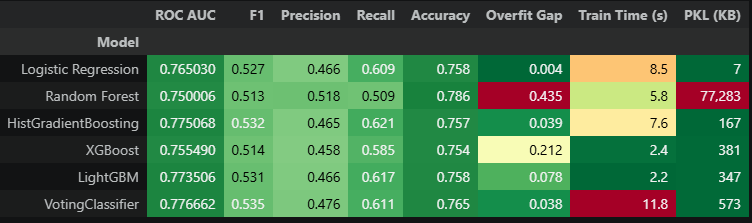

models with set two features:


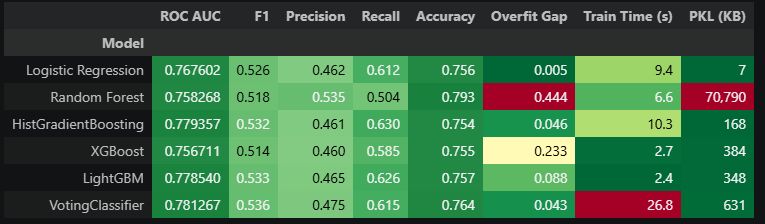

models without features selection, including feature eng:


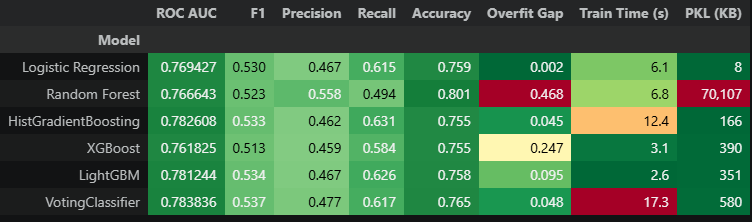

# Confussion Matrix

In [29]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import joblib

pipeline = joblib.load("src/product_pipeline.pkl")
threshold = joblib.load("src/opt_threshold.pkl")

# Probabilities
probs = pipeline.predict_proba(X_test)[:, 1]

# Predictions using optimized threshold
preds = (probs >= threshold).astype(int)

# Metrics
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)
roc_auc = roc_auc_score(y_test, probs)

# Confusion matrix
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(cm)
print()

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"ROC AUC  : {roc_auc:.3f}")
print()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)
print()

print(classification_report(y_test, preds))

Confusion Matrix
[[4058  615]
 [ 558  769]]

Accuracy : 0.804
Precision: 0.556
Recall   : 0.580
F1 Score : 0.567
ROC AUC  : 0.826

TN: 4058
FP: 615
FN: 558
TP: 769

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4673
           1       0.56      0.58      0.57      1327

    accuracy                           0.80      6000
   macro avg       0.72      0.72      0.72      6000
weighted avg       0.81      0.80      0.81      6000



c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [30]:
specificity = tn / (tn + fp)
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"Specificity (TNR): {specificity:.3f}")
print(f"False Positive Rate: {false_positive_rate:.3f}")
print(f"False Negative Rate: {false_negative_rate:.3f}")

Specificity (TNR): 0.868
False Positive Rate: 0.132
False Negative Rate: 0.420


In [31]:
preprocessor = pipeline.named_steps['preprocessor']
model = pipeline.named_steps['model']

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(20)

,feature,importance
2,num__X12,481
0,num__X1,363
9,num__X19,258
10,num__X20,225
8,num__X18,223
1,num__X5,217
3,num__X13,197
13,num__X23,189
24,rep__X6,187
6,num__X16,185


<Figure size 1000x800 with 0 Axes>

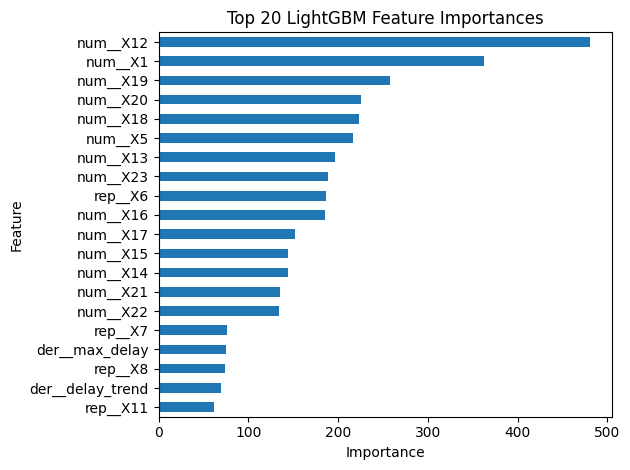

In [32]:
plt.figure(figsize=(10, 8))

importance_df.head(20).sort_values(
    'importance'
).plot(
    x='feature',
    y='importance',
    kind='barh',
    legend=False
)

plt.title("Top 20 LightGBM Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig('plots/lightgbm_feature_importance.png', dpi=150)
plt.show()